In [1]:
import sys
if ".." not in sys.path:
    sys.path.append("..")
import numpy as np
from scipy import interpolate
from matplotlib import pyplot as plt
from fast_legged_planner_py.robot_interface.ur5_robotinterface import UR5_RobotInterface
from numpy.linalg import norm
import pinocchio as pin
ur5 = UR5_RobotInterface()

/home/yip/miniconda3/envs/robotic_course/lib/python3.9/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 1.21.0)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


You can open the visualizer by visiting the following URL:
http://127.0.0.1:7015/static/


In [2]:
# print("\n".join([f.name+"\t"+str(f.parent)+"\t"+str(f.type) for f in ur5.robot.model.frames]))
# ur5.robot.model.frames[22].placement.translation
ur5.robot.model.getFrameId("wrist_1_joint")
ur5.print_frames()

0 universe
1 root_joint
2 world
3 world_joint
4 base_link
5 base_link-base_fixed_joint
6 base
7 shoulder_pan_joint
8 shoulder_link
9 shoulder_lift_joint
10 upper_arm_link
11 elbow_joint
12 forearm_link
13 wrist_1_joint
14 wrist_1_link
15 wrist_2_joint
16 wrist_2_link
17 wrist_3_joint
18 wrist_3_link
19 ee_fixed_joint
20 ee_link
21 wrist_3_link-tool0_fixed_joint
22 tool0


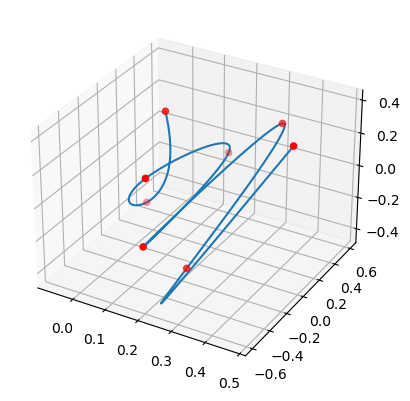

In [2]:
# 3D Spline gen
x_range = 6*np.pi
x = np.linspace(0, x_range, 8)
y = np.array([np.cos(x)+0.2*x, 6*np.sin(x), 4*np.cos(x)])*0.1
# Periodic condition is satisfied because y coordinates of points on the ends are equivalent
ax = plt.axes(projection='3d')
xx = np.linspace(0, x_range, 2000)
bspl = interpolate.make_interp_spline(x, y, k=3, bc_type=None, axis=1)
ax.plot3D(*bspl(xx))
ax.scatter3D(*y, color='red')
plt.show()

# Visualize
last_q = None
for pos in xx:
    last_q = ur5.vis_target_reach_3D(bspl(pos), last_q) 

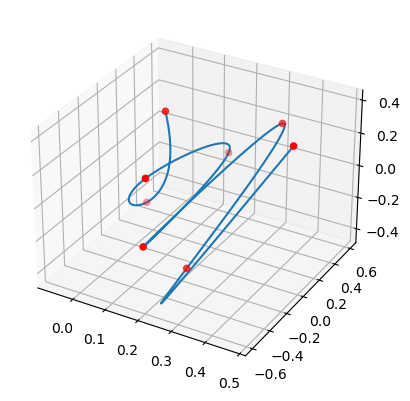

In [2]:
# 6D Spline gen
x_range = 6*np.pi
x = np.linspace(0, x_range, 8)
y = np.array([np.cos(x)+0.2*x, 6*np.sin(x), 4*np.cos(x),    # Pos
              np.ones(x.shape), np.cos(3*x), np.sin(3*x), 10*np.sin(x)])*0.1 # Axis-Angle(x,y,z,theta)
# Periodic condition is satisfied because y coordinates of points on the ends are equivalent
ax = plt.axes(projection='3d')
xx = np.linspace(0, x_range, 2000)
bspl = interpolate.make_interp_spline(x, y, k=3, bc_type=None, axis=1)
ax.plot3D(*bspl(xx)[:3])
ax.scatter3D(*y[:3], color='red')
plt.show() # Only pos is plotted

# Visualize
last_q = None
for pos in xx:
    theta = bspl(pos)[6]
    normalized_axis = bspl(pos)[3:6]/norm(bspl(pos)[3:5])

    SE3target = pin.XYZQUATToSE3(
        np.concatenate((bspl(pos)[:3], np.array([np.cos(theta/2)]),
                        normalized_axis*np.sin(theta/2))))
    
    last_q = ur5.vis_target_reach_6D(SE3target, last_q) # is more smooth than without last_q


# Technical Experiments